In [42]:
# 1. MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# 2. IMPORTS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [44]:
# 3. PATHS
base_dir = '/content/drive/MyDrive/Data'
train_path = base_dir + '/train'
valid_path   = base_dir + '/valid'
test_path  = base_dir + '/test'

In [45]:
# 4. CHECKING
import os
for split in ['train', 'valid', 'test']:
    path = f'/content/drive/MyDrive/Data/{split}'
    for cls in os.listdir(path):
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"{split}/{cls}: {count} images")

train/normal: 148 images
train/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images
train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
train/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 images
valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 images
valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 images
valid/normal: 13 images
test/large.cell.carcinoma: 51 images
test/squamous.cell.carcinoma: 90 images
test/normal: 54 images
test/adenocarcinoma: 120 images


In [46]:
#  5. DATA GENERATORS

# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=False
)

# Validation/Test Data

valid_datagen = ImageDataGenerator(
    rescale=1./255
)
test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
)
valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
print("\nClass Labels:")
print(train_generator.class_indices)
print("\nTraining Samples:", train_generator.samples)
print("Validation Samples:", valid_generator.samples)
print("Testing Samples:", test_generator.samples)


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.

Class Labels:
{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}

Training Samples: 613
Validation Samples: 72
Testing Samples: 315


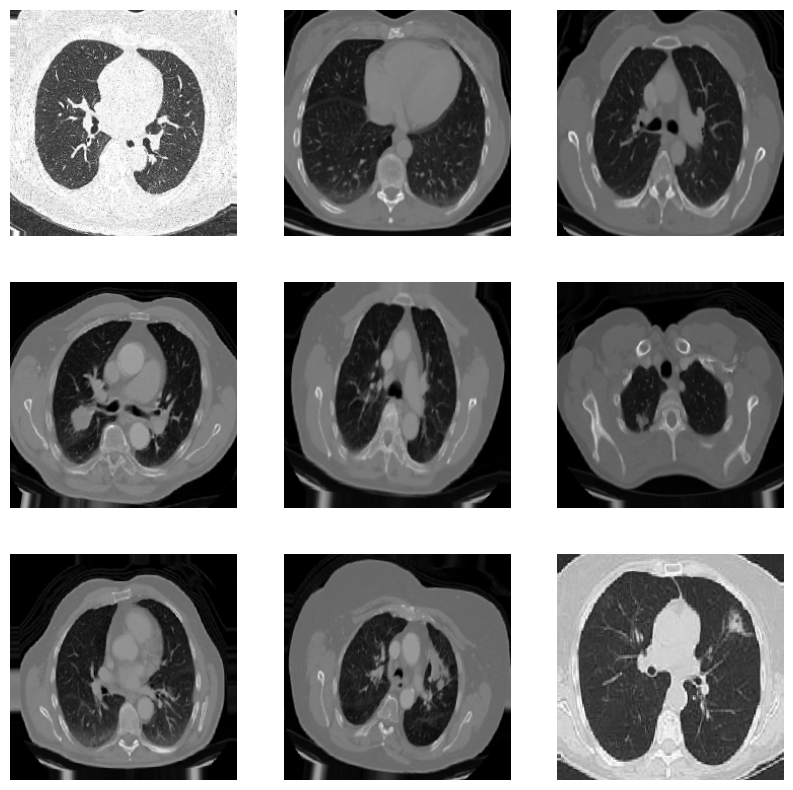

In [47]:
# 6. VISUALIZE IMAGES
images, labels = next(train_generator)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [48]:
# 7. MODEL (MobileNetV2)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [49]:
# 8. COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
# 9. CHECKPOINT
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [51]:
print(train_generator.class_indices)
print(test_generator.class_indices)

{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
{'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}


In [52]:
# 10. TRAIN
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3064 - loss: 1.6902
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.3181 - loss: 1.5685 - val_accuracy: 0.5000 - val_loss: 1.1420
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3775 - loss: 1.3685
Epoch 2: val_accuracy did not improve from 0.50000
20/20 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.4470 - loss: 1.2561 - val_accuracy: 0.5000 - val_loss: 1.0453
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4691 - loss: 1.1781
Epoch 3: val_accuracy did not improve from 0.50000
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5090 - loss: 1.1000 - val_accuracy: 0.4722 - val_loss: 0.9905
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5135 - loss: 0.9965
Epoch 4: val_accuracy improved from 0.50000 to 0.51389, saving model to best_model.

In [53]:
# 11. LOAD BEST MODEL & EVALUATE ON TEST
test_loss, test_acc = model.evaluate(test_generator)
print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6857 - loss: 0.8013

Test Accuracy: 0.6857143044471741
Test Loss: 0.8013045191764832


In [54]:
# 12. CLASSIFICATION REPORT
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())
print("\nClass Names:")
print(class_names)
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step

Class Names:
['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.64      0.75      0.69       120
   large.cell.carcinoma       0.61      0.53      0.57        51
                 normal       0.95      0.98      0.96        54
squamous.cell.carcinoma       0.61      0.51      0.56        90

               accuracy                           0.69       315
              macro avg       0.70      0.69      0.70       315
           weighted avg       0.68      0.69      0.68       315



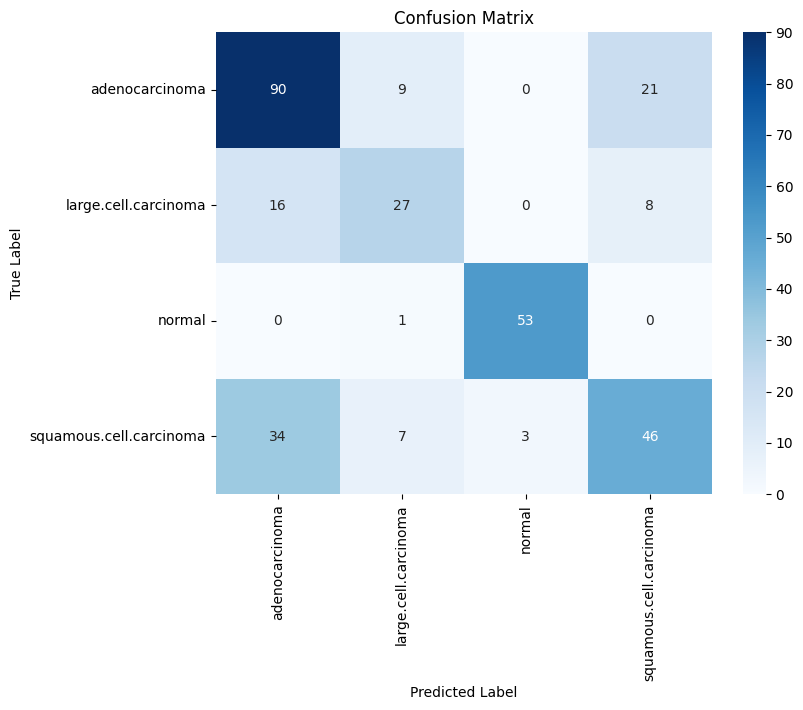

In [55]:
# ─── 13. CONFUSION MATRIX ─────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

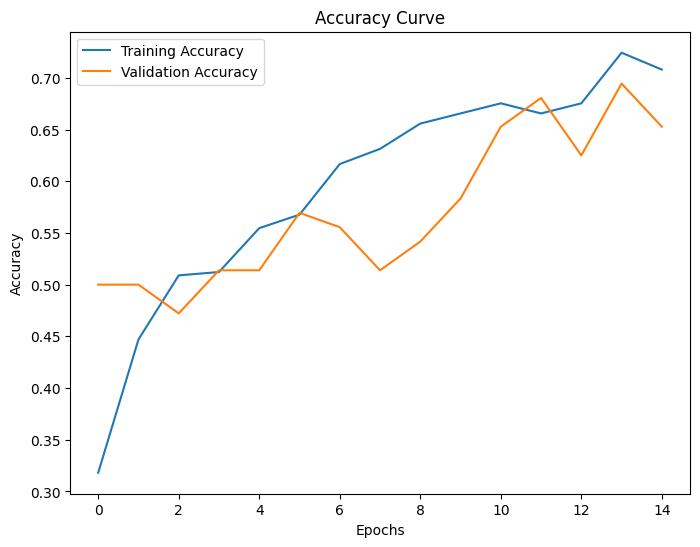

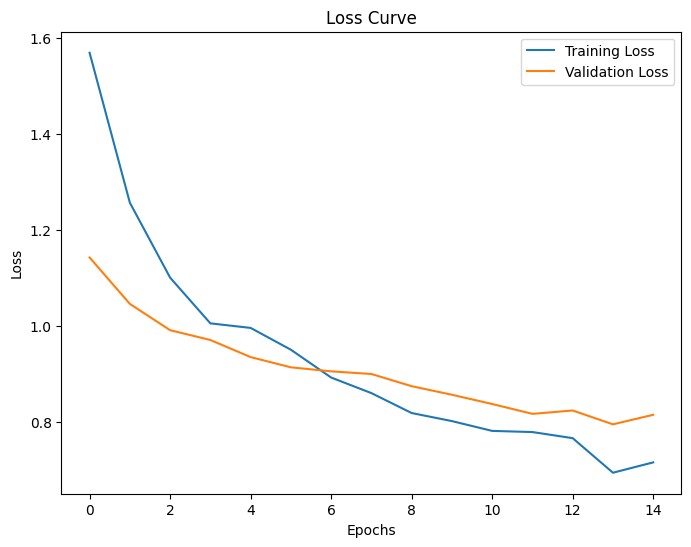

In [56]:
# ─── 14. ACCURACY & LOSS PLOTS ────────────────────────────────────

plt.figure(figsize=(8,6))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.figure(figsize=(8,6))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# ─── 15. SAVE FINAL MODEL ────────────────────────────────────
model.save("lung_cancer_model.keras")
print("\nModel Saved Successfully")